In [2]:
%pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 1.8 MB/s eta 0:00:00


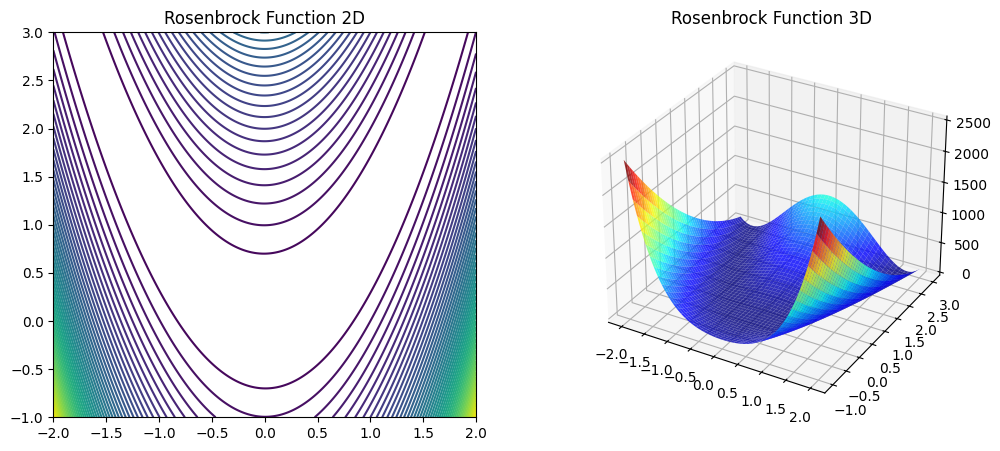

Initial guess [-1, 1], Result: [0.99999551 0.99999102], Value: 2.012817396886289e-11, Success: True, Iterations: 31, Time: 0.0176 sec
Initial guess [2, 2], Result: [0.99999565 0.99999129], Value: 1.8932783589357527e-11, Success: True, Iterations: 30, Time: 0.0164 sec
Initial guess [0, 0], Result: [0.99999467 0.99998932], Value: 2.8439915001532524e-11, Success: True, Iterations: 19, Time: 0.0102 sec
PyGAD initial guess [-1, 1], Solution: [1.00521348 1.01036839], Value: rosenbrock(solution), iterations: 2000, Time: 1.1777 sec
PyGAD initial guess [2, 2], Solution: [0.99963712 0.99954812], Value: rosenbrock(solution), iterations: 2000, Time: 1.1603 sec
PyGAD initial guess [0, 0], Solution: [1.00381102 1.00814469], Value: rosenbrock(solution), iterations: 2000, Time: 1.2635 sec


In [12]:
import numpy as np
#import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[-1, 1], [2, 2], [0, 0]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: rosenbrock(solution), iterations: {iters}, Time: {elapsed_time:.4f} sec")
    # Uncomment to plot fitness: ga_instance.plot_fitness()

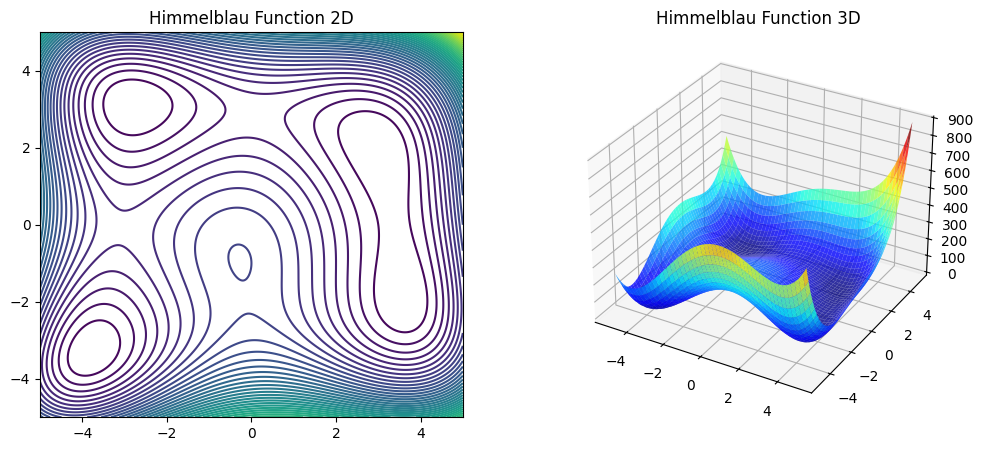

Initial guess [0, 0], Result: [2.99999994 1.99999999], Value: 1.3782324420898585e-13, Success: True, Iterations: 10
Initial guess [-4, 4], Result: [-2.80511803  3.13131251], Value: 1.0206442951662802e-13, Success: True, Iterations: 10
Initial guess [4, 0], Result: [ 3.58442834 -1.84812653], Value: 2.2638413847109013e-16, Success: True, Iterations: 8
PyGAD initial guess [0, 0], Solution: [2.9998965  2.00179787], Value: 5.167019590384731e-05
PyGAD initial guess [-4, 4], Solution: [3.01260464 1.99698088], Value: 0.005295413797349144
PyGAD initial guess [4, 0], Solution: [ 3.58309652 -1.84838689], Value: 9.629848401120086e-05


In [ ]:
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.show()

# Scipy Optimization
init_guesses = [[0, 0], [-4, 4], [4, 0]]
for guess in init_guesses:
    result = minimize(himmelblau, guess, method='BFGS')
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}") # TODO include time taken

# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
for guess in init_guesses:
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}") # TODO include iterations and time taken
# ga_instance.plot_fitness()